<a href="https://colab.research.google.com/github/winpeperk/dls/blob/main/week_03_composition_model_selection/Homework/hw_3_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

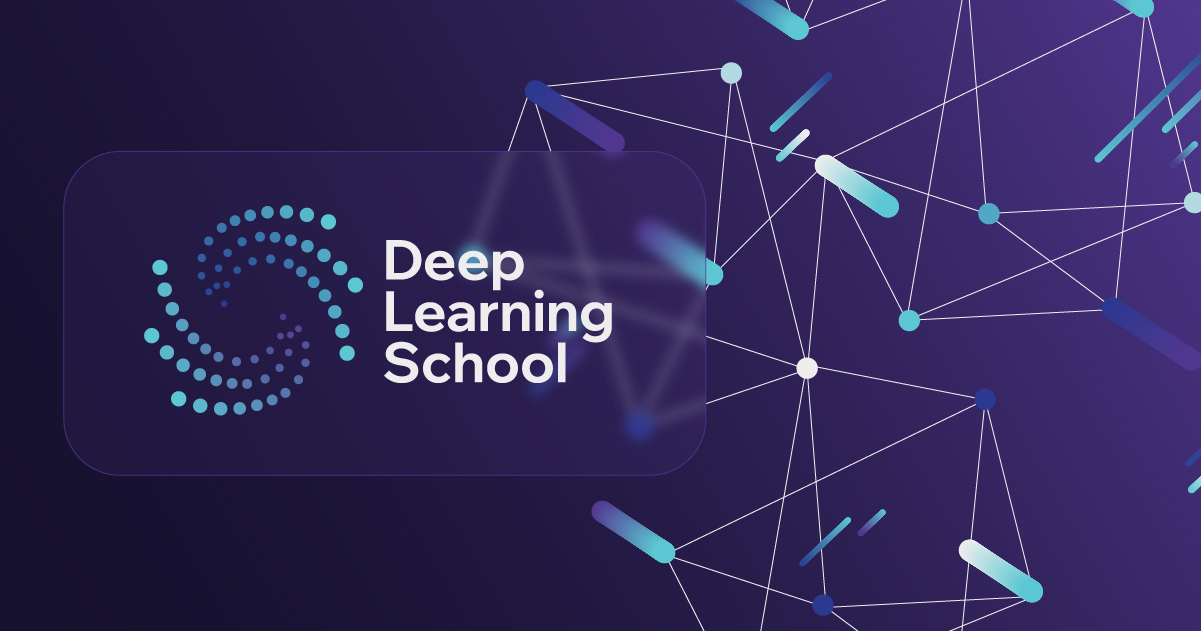

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Решение конкурса на kaggle</b></h1>



Это домашнее задание посвящено полноценному решению задачи машинного обучения.

Есть две части этого домашнего задания:

### Отправить ваши предсказания в Stepik.
За прохождение определенных порогов будут начисляться баллы. Эта часть оценивается из 5 баллов.

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на две части.
* `train.csv`. На этом наборе данных вам необходимо создать и обучить модель. Подробное описание файла есть в ноутбуке.
* `test.csv`. В каждой строчке файла `test.csv` указаны признаки тестовых объектов. Предсказания для этого набора необходимо записать в файл submission.csv и сдать в соответствующий шаг на Stepik. Количество попыток ограничено 100 штук.

Отправлять в Stepik вы будете файл с ответами `my_submission.csv`. В этом файле вам необходимо для каждого объекта из датасета предсказать вероятность класса 1. Мы подготовили для вас файл с примером посылки `submission.csv`. Ваш файл должен быть оформлен таким же образом. В ноутбуке есть пример оформления файла посылки. Для отправки файла с предсказаниями на Stepik есть отдельный шаг.

### Сделать полноценный отчет о вашей работе.
Опишите, как вы обработали данные, какие модели попробовали и какие результаты получились (максимум 10 баллов). За каждую выполненную часть будет начислено определенное количество баллов. В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается из 10 баллов.

**Вторая часть будет проверяться в формате peer-review. Т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.**

### Контест на Kaggle
Для вашего удобства мы подготовили [контест на Kaggle](https://www.kaggle.com/c/advanced-dls-spring-2021/). Тестирующая система на Kaggle выдает те же баллы, что и Stepik. Мы рекомендуем в качестве основной тестирующей системы использовать именно Kaggle, а затем сдать лучшую посылку на Stepik. Так вы привыкните работать с Kaggle.

### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


Данные: [train.csv](https://drive.google.com/file/d/1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K/view?usp=share_link),
[test.csv](https://drive.google.com/file/d/1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r/view?usp=share_link), [submission.csv](https://drive.google.com/file/d/199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y/view?usp=share_link).

Если ссылки на данные не работают, их можно скачать [на Kaggle](https://www.kaggle.com/competitions/advanced-dls-spring-2021/data).

# Метрика

Перед решением любой задачи важно понимать, как будет оцениваться ваше решение. В данном случае мы используем стандартную для задачи классификации метрику ROC-AUC. Ее можно вычислить, используя только предсказанные вероятности и истинные классы без конкретного порога классификации + она работает даже если классы в данных сильно несбалансированны (примеров одного класса в десятки раз больше примеров другого). Именно поэтому она очень удобна для соревнований.

Посчитать ее легко:


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

np.float64(0.8333333333333333)

# Первая часть. Исследование

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 105MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 102MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 39.9MB/s]


In [ ]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

train_copy, test_copy = train.copy(), test.copy()

In [ ]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

Заметим, что числовой признак 'TotalSpent' хранится как строка. Преобразуем его в численный формат.

In [ ]:
train['TotalSpent'].dtype

dtype('O')

In [ ]:
train['TotalSpent'] = pd.to_numeric(train['TotalSpent'], errors='coerce')
test['TotalSpent'] = pd.to_numeric(test['TotalSpent'], errors='coerce')

Построим гистограммы для численных признаков с помощью seaborn.

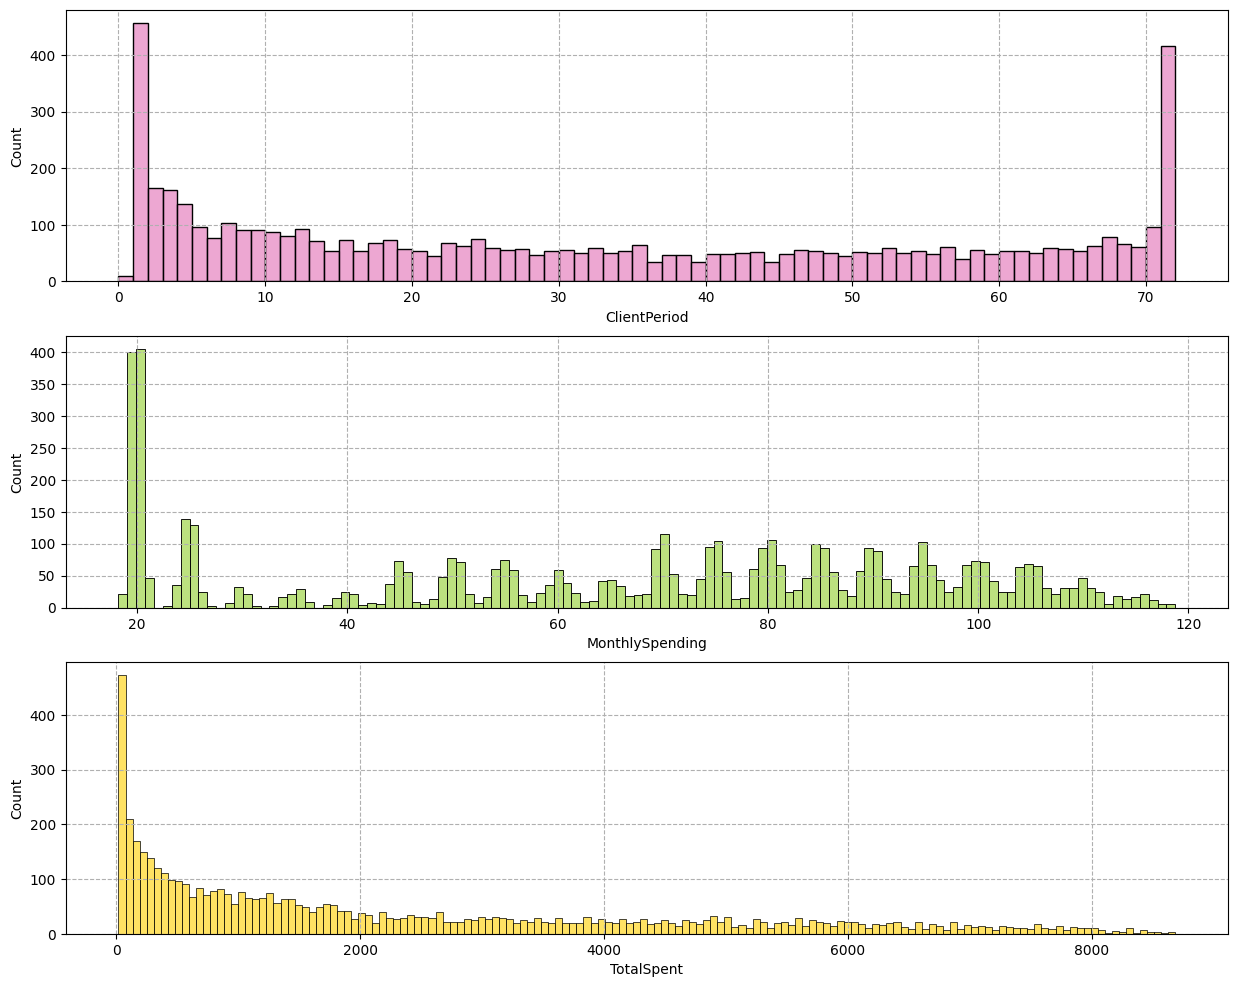

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(15, 12))

for i, num_col in enumerate(num_cols):
  bins = round(train[num_col].max())
  sns.histplot(data=train[num_col],
               color=sns.color_palette('Set2')[i+3],
               bins=bins if bins <= 150 else 150,
               ax=ax[i])
  ax[i].grid(True, linestyle='--')
  ax[i].set_xlabel(num_col)

plt.show()

Для каждого категориального признака построим распределение его значений с помощью plt.

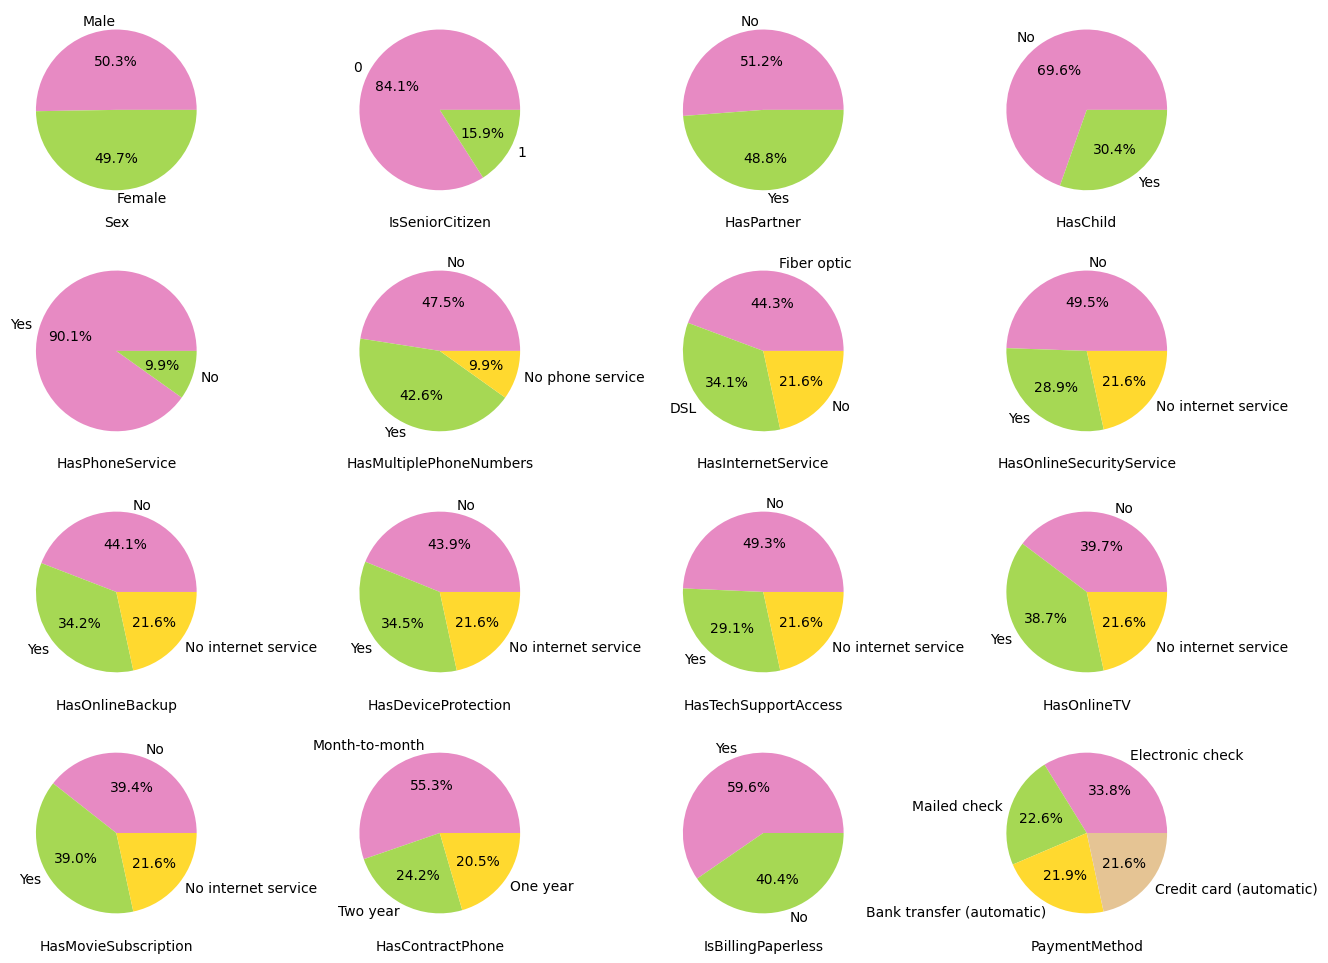

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(16, 12))

for i, cat_col in enumerate(cat_cols):
  distribution = train[cat_col].value_counts()
  row, col = i // 4, i % 4

  ax[row, col].pie(x=distribution,
                   labels=distribution.index,
                   colors=sns.color_palette('Set2')[3:],
                   autopct='%1.1f%%')
  ax[row, col].set_xlabel(cat_col)
  ax[row, col]

plt.show()

Посмотрим на распределение целевой переменной.

In [ ]:
train[target_col].value_counts()

,count
Churn,
0,3898
1,1384


`Conclusion`: Классы несбалансированы. Объектов нулевого класса (оставшихся клиентов) в 2.8 раз больше, чем объектов 1 (ушедших клиентов).

Посмотрим, есть ли пропущенные значения у численных колонок.

In [ ]:
train[num_cols].isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,9


Заполним пропуски в 'TotalSpent' медианным значением.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
train[num_cols] = imputer.fit_transform(train[num_cols])
test[num_cols] = imputer.transform(test[num_cols])

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.

2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Закодируем категориальные признаки с помощью OneHotEncoder.

In [ ]:
enc = OneHotEncoder(drop='first',
                    handle_unknown='ignore',
                    sparse_output=False)
train_cat_cols = pd.DataFrame(enc.fit_transform(train[cat_cols]), columns=enc.get_feature_names_out())
test_cat_cols = pd.DataFrame(enc.transform(test[cat_cols]), columns=enc.get_feature_names_out())

train = train.drop(columns=cat_cols)
train = pd.concat([train, train_cat_cols], axis=1)

test = test.drop(columns=cat_cols)
test = pd.concat([test, test_cat_cols], axis=1)

Отмасштабируем числовые признаки.

In [ ]:
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

In [ ]:
train.head()

,ClientPeriod,MonthlySpending,TotalSpent,Churn,Sex_Male,IsSeniorCitizen_1,HasPartner_Yes,HasChild_Yes,HasPhoneService_Yes,HasMultiplePhoneNumbers_No phone service,...,HasOnlineTV_No internet service,HasOnlineTV_Yes,HasMovieSubscription_No internet service,HasMovieSubscription_Yes,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.920767,-1.505447,-0.557323,0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.613288,-1.294998,-0.184235,0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-1.279005,0.363737,-0.976549,1,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.016173,0.476418,0.123552,0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.124450,1.667856,1.970998,0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
X_train, y_train = train.drop(columns=[target_col]), train[target_col]

Обучим LogisticRegressionCV на наших данных.

In [ ]:
clf = LogisticRegressionCV(cv=5,
                           Cs=[100, 10, 1, 0.1, 0.01, 0.001],
                           scoring='roc_auc')
clf.fit(X_train, y_train)
roc_auc = roc_auc_score(y_train, clf.predict_proba(X_train)[:,1])
best_C = clf.C_[0]
print(f'Best roc_auc: {roc_auc}')
print(f'Best C: {best_C}')

Best roc_auc: 0.8489755566067674
Best C: 10.0


Выпишите какое лучшее качество и с какими параметрами вам удалось получить.

`Conclusion`: При C=10 в LogisticRegressionCV имеем наибольший roc_auc = 0.8490.

## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные значения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

Разделим данные на обучающую и валидационную выборки.

In [ ]:
X_train, X_valid, y_train, y_valid = \
          train_test_split(train_copy[feature_cols], train_copy[target_col], test_size=0.33)

In [ ]:
cat_clf = CatBoostClassifier(random_seed=42,
                             eval_metric='AUC',
                             cat_features=cat_cols,
                             verbose=0)
cat_clf.fit(X_train, y_train)
roc_auc = roc_auc_score(y_valid, cat_clf.predict_proba(X_valid)[:, 1])

In [ ]:
print(f'Без подбора гиперпараметров roc_auc на valid: {roc_auc}')

Без подбора гиперпараметров roc_auc на valid: 0.8441049860933507


Подребём разные значения гиперпараметров `depth` и `learning_rate`.

In [ ]:
param_grid = {'depth': [4, 6, 8],
              'learning_rate': [0.01, 0.1]}

cat_clf = CatBoostClassifier(random_seed=42,
                             eval_metric='AUC',
                             cat_features=cat_cols,
                             verbose=0)

result = cat_clf.grid_search(
    param_grid=param_grid,
    X=train_copy[feature_cols],
    y=train_copy[target_col],
    cv=5,
    verbose=False,
    partition_random_seed=42,
    stratified=True)


bestTest = 0.8482772821
bestIteration = 986

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8494188973
bestIteration = 105

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8477419355
bestIteration = 561

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8479569892
bestIteration = 62

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8451635781
bestIteration = 679

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.8453099977
bestIteration = 27

Metric AUC is not calculated on train by default. To cal

In [ ]:
result['params']

{'depth': 4, 'learning_rate': 0.1}

In [ ]:
np.max(result['cv_results']['test-AUC-mean'])

np.float64(0.8477569991645526)

Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

`Conclusion`: При обучении CatBoostClassifier на разных значениях гиперпараметров depth и learning_rate лучшим показателем оказался roc_auc = 0.8478. Лучшие гиперпараметры: depth=4, learning_rate=0.1.

# Предсказания

In [ ]:
best_model = clf

In [ ]:
submission = pd.read_csv('./submission.csv')
submission['Churn'] = best_model.predict_proba(test)[:, 1]
submission.to_csv('./my_submission.csv')

Лучшее решение отправьте в Stepik.

На степике 0.8458.